In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

In [ ]:
df_balanceado = pd.read_csv('/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB_balanceado_completo.csv')

In [ ]:
X = df_balanceado['text_cleaned']
y = df_balanceado['category_single']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Vectorizar texto con TF-IDF
vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [ ]:
# Entrenar Naive Bayes
model = MultinomialNB()
model.fit(X_train_vect, y_train)

MultinomialNB()

In [ ]:
# Predicción
y_pred = model.predict(X_test_vect)

In [ ]:
# Evaluación
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred))

REPORTE DE CLASIFICACIÓN:
                   precision    recall  f1-score   support

             edad       0.97      0.30      0.45      1979
            etnia       0.98      0.09      0.16      1408
           género       0.94      0.26      0.40      2455
not_ciberbullying       0.57      1.00      0.73      8009
             odio       0.96      0.13      0.23      1260
            otros       0.89      0.04      0.07       453

         accuracy                           0.61     15564
        macro avg       0.89      0.30      0.34     15564
     weighted avg       0.76      0.61      0.53     15564



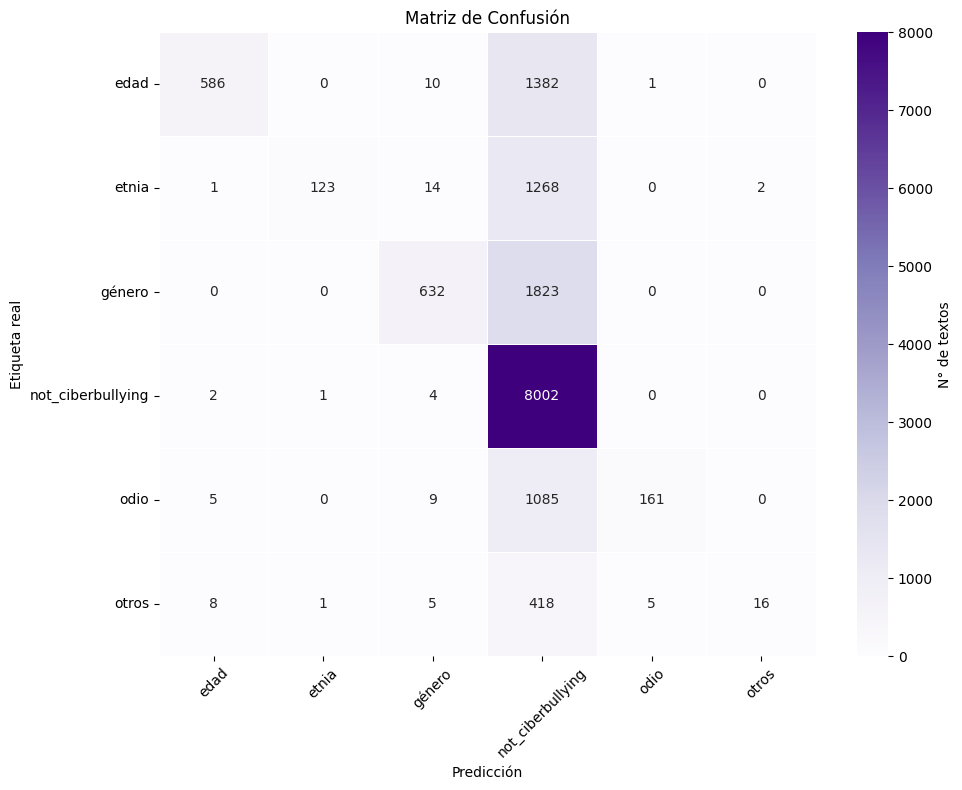

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Obtener las etiquetas únicas y ordenarlas
labels = sorted(y.unique())  # usa las clases del dataset original

# Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Visualizar con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, cbar_kws={"label": "N° de textos"})
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Definir pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

# Hiperparámetros a probar
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__stop_words': [None, 'spanish'],
    'tfidf__min_df': [1, 5],
    'nb__alpha': [0.1, 0.3, 1.0]
}

# Búsqueda con validación cruzada
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Entrenar búsqueda
grid.fit(X_train, y_train)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
36 fits failed out of a total of 72.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
36 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, r

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('nb', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'nb__alpha': [0.1, 0.3, 1.0], 'tfidf__min_df': [1, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)],
                         'tfidf__stop_words': [None, 'spanish']},
             scoring='f1_macro', verbose=2)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predicción y métricas
y_pred = grid.predict(X_test)
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)

print("\nReporte de clasificación en test set:")
print(classification_report(y_test, y_pred))


Mejores hiperparámetros encontrados:
{'nb__alpha': 0.1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__stop_words': None}

Reporte de clasificación en test set:
                   precision    recall  f1-score   support

             edad       0.93      0.84      0.89      1979
            etnia       0.96      0.72      0.83      1408
           género       0.89      0.78      0.83      2455
not_ciberbullying       0.83      0.97      0.90      8009
             odio       0.97      0.72      0.83      1260
            otros       0.99      0.61      0.75       453

         accuracy                           0.87     15564
        macro avg       0.93      0.77      0.84     15564
     weighted avg       0.88      0.87      0.87     15564



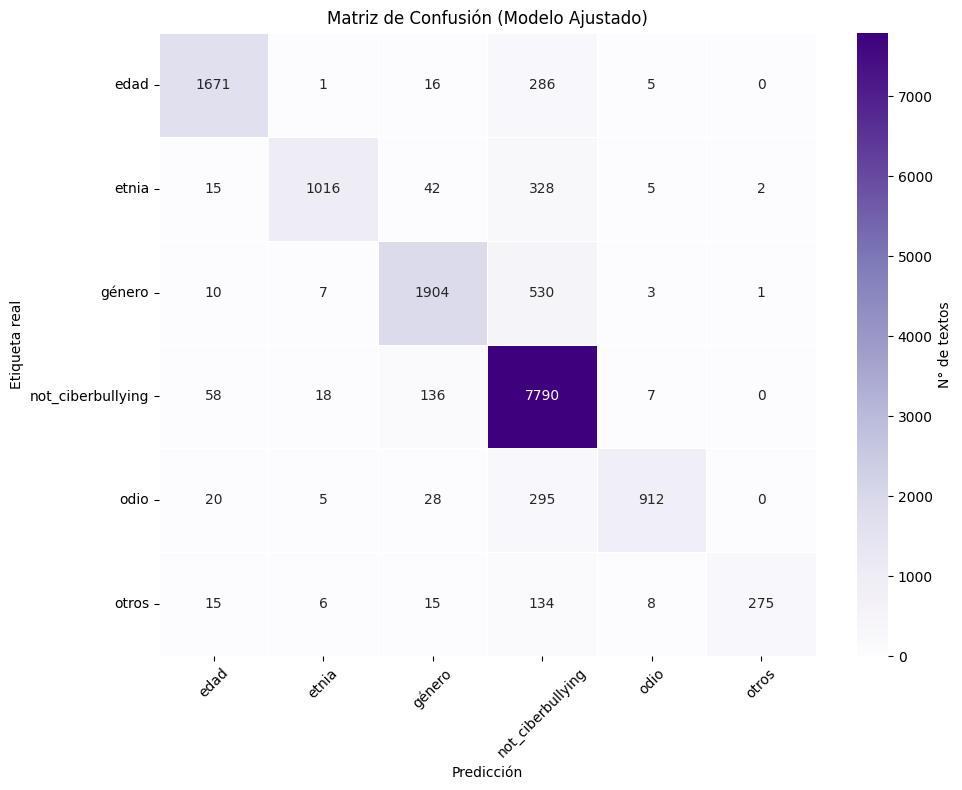

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, cbar_kws={"label": "N° de textos"})
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión (Modelo Ajustado)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [17]:
import joblib

# Guardar el modelo entrenado con los mejores hiperparámetros
modelo_guardado = 'modelo_naive_bayes_ajustado.joblib'
joblib.dump(grid.best_estimator_, modelo_guardado)

# Mostrar hiperparámetros finales del modelo entrenado
print("🔧 Hiperparámetros del mejor modelo encontrado:")
for param, valor in grid.best_params_.items():
    print(f"{param}: {valor}")

print(f"\n📁 Modelo guardado como: {modelo_guardado}")


🔧 Hiperparámetros del mejor modelo encontrado:
nb__alpha: 0.1
tfidf__min_df: 1
tfidf__ngram_range: (1, 2)
tfidf__stop_words: None

📁 Modelo guardado como: modelo_naive_bayes_ajustado.joblib
